## Import data


In [2]:
import polars as pl
import datetime as dt

af2_cutoff = dt.datetime(2018, 5, 1, tzinfo=dt.timezone.utc)

pdb_af3 = pl.read_parquet("../../data/pdb/triad/staged/pdb_triad.af3_rmsd.parquet")
pdb_af3 = pdb_af3.with_columns(
    pl.when(pl.col("pdb_date") < af2_cutoff)
    .then(pl.lit(True))
    .otherwise(pl.lit(False))
    .alias("af2_pre_cutoff")
)

## Plotting methods


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Patch
from scipy import stats


def plot_rmsd_compare_af(
    df_af3: pl.DataFrame,
    title: str | None = None,
) -> plt.Figure:
    """
    Compare a single RMSD type between AF3 and AF2M models.
    For each model we plot two boxplots (pre- and post-training cutoff),
    annotate legend entries with sample counts, and compute
    Spearman correlation + two-sided paired t-test on matching PDB IDs.
    """
    # Column names
    col_af3 = "cdr_rmsd_af3_4"
    col_af2 = "cdr_rmsd"

    # Prepare pre/post subsets and counts
    af3_pre = df_af3.filter(pl.col("replication"))
    af3_post = df_af3.filter(~pl.col("replication"))
    af2_pre = df_af3.filter(pl.col("af2_pre_cutoff"))
    af2_post = df_af3.filter(~pl.col("af2_pre_cutoff"), pl.col(col_af2).is_not_null())

    n_af3_pre = af3_pre.height
    n_af3_post = af3_post.height
    n_af2_pre = af2_pre.height
    n_af2_post = af2_post.height

    # Boxplot data
    pre_af3_vals = af3_pre.select(pl.col(col_af3)).to_numpy().flatten()
    post_af3_vals = af3_post.select(pl.col(col_af3)).to_numpy().flatten()
    pre_af2_vals = af2_pre.select(pl.col(col_af2)).to_numpy().flatten()
    post_af2_vals = af2_post.select(pl.col(col_af2)).to_numpy().flatten()

    # Build matched datasets on 'pdb'
    # Pre-training matched
    joined_pre = af3_pre.select(["pdb", pl.col(col_af3).alias("af3")]).join(
        af2_pre.select(["pdb", pl.col(col_af2).alias("af2")]),
        on="pdb",
        how="inner",
    )
    arr_af3_pre = joined_pre["af3"].to_numpy()
    arr_af2_pre = joined_pre["af2"].to_numpy()

    # Post-training matched
    joined_post = af3_post.select(["pdb", pl.col(col_af3).alias("af3")]).join(
        af2_post.select(["pdb", pl.col(col_af2).alias("af2")]),
        on="pdb",
        how="inner",
    )
    arr_af3_post = joined_post["af3"].to_numpy()
    arr_af2_post = joined_post["af2"].to_numpy()

    # Compute Spearman + paired t-test
    rho_pre, p_s_pre = stats.spearmanr(arr_af3_pre, arr_af2_pre)
    t_pre, p_t_pre = stats.ttest_rel(arr_af3_pre, arr_af2_pre)
    rho_post, p_s_post = stats.spearmanr(arr_af3_post, arr_af2_post)
    t_post, p_t_post = stats.ttest_rel(arr_af3_post, arr_af2_post)

    # Set up plot
    x = np.array([0, 1])
    width = 0.3
    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot AF3
    ax.boxplot(
        pre_af3_vals,
        positions=[x[0] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:blue", edgecolor="black"),
        whiskerprops=dict(color="tab:blue"),
        capprops=dict(color="tab:blue"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:blue"),
    )
    ax.boxplot(
        post_af3_vals,
        positions=[x[0] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:orange", edgecolor="black"),
        whiskerprops=dict(color="tab:orange"),
        capprops=dict(color="tab:orange"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:orange"),
    )

    # Plot Boltz
    ax.boxplot(
        pre_af2_vals,
        positions=[x[1] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:green", edgecolor="black"),
        whiskerprops=dict(color="tab:green"),
        capprops=dict(color="tab:green"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:green"),
    )
    ax.boxplot(
        post_af2_vals,
        positions=[x[1] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:red", edgecolor="black"),
        whiskerprops=dict(color="tab:red"),
        capprops=dict(color="tab:red"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:red"),
    )

    # Labels
    ax.set_xticks(x)
    ax.set_xticklabels(
        ["AF3", "AF2M"],
    )
    ax.set_ylabel("CDR RMSD (Å)")
    if title:
        ax.set_title(title)

    # Legend with counts
    legend_handles = [
        Patch(
            facecolor="tab:blue", edgecolor="black", label=f"AF3 pre (n={n_af3_pre})"
        ),
        Patch(
            facecolor="tab:orange",
            edgecolor="black",
            label=f"AF3 post (n={n_af3_post})",
        ),
        Patch(
            facecolor="tab:green",
            edgecolor="black",
            label=f"AF2M pre (n={n_af2_pre})",
        ),
        Patch(
            facecolor="tab:red",
            edgecolor="black",
            label=f"AF2M post (n={n_af2_post})",
        ),
    ]
    ax.legend(handles=legend_handles, loc="upper right")

    stats_text = (
        f"\nPre-cutoff intersection AF3 vs AF2M:\n  n={len(arr_af3_pre)},\n  Spearman ρ={rho_pre:.2f} (p={p_s_pre:.2g}),\n  t={t_pre:.2f} (p={p_t_pre:.2g})\n\n"
        # f"Post-cutoff intersection AF3 vs AF2M:\n  n={len(arr_af3_post)},\n  Spearman ρ={rho_post:.2f} (p={p_s_post:.2g}),\n  t={t_post:.2f} (p={p_t_post:.2g})"
    )
    # legend_handles.append(Patch(facecolor="none", edgecolor="none", label=stats_text))

    ax.legend(handles=legend_handles, loc="upper right")

    # Annotate stats
    print(stats_text)
    # ax.text(
    #     1.01,
    #     0.8,
    #     stats_text,
    #     transform=ax.transAxes,
    #     fontsize=8,
    #     bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
    # )

    plt.tight_layout()
    return fig

/tmp/ipykernel_2897700/3734001845.py:62: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_post, p_t_post = stats.ttest_rel(arr_af3_post, arr_af2_post)



Pre-cutoff intersection AF3 vs AF2M:
  n=67,
  Spearman ρ=0.12 (p=0.31),
  t=-6.84 (p=3.1e-09)




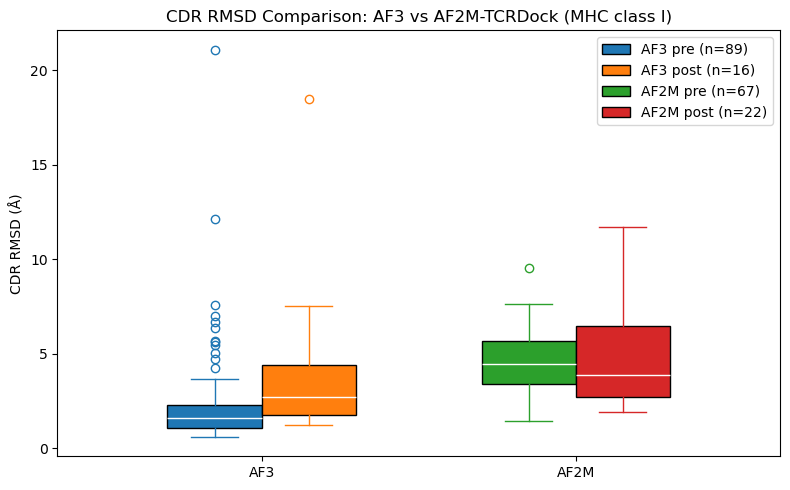

In [4]:
fig = plot_rmsd_compare_af(
    pdb_af3.filter(pl.col("mhc_class") == "I"),
    title="CDR RMSD Comparison: AF3 vs AF2M-TCRDock (MHC class I)",
)


Pre-cutoff intersection AF3 vs AF2M:
  n=31,
  Spearman ρ=0.68 (p=2.3e-05),
  t=-2.02 (p=0.052)




/tmp/ipykernel_2897700/3734001845.py:62: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_post, p_t_post = stats.ttest_rel(arr_af3_post, arr_af2_post)


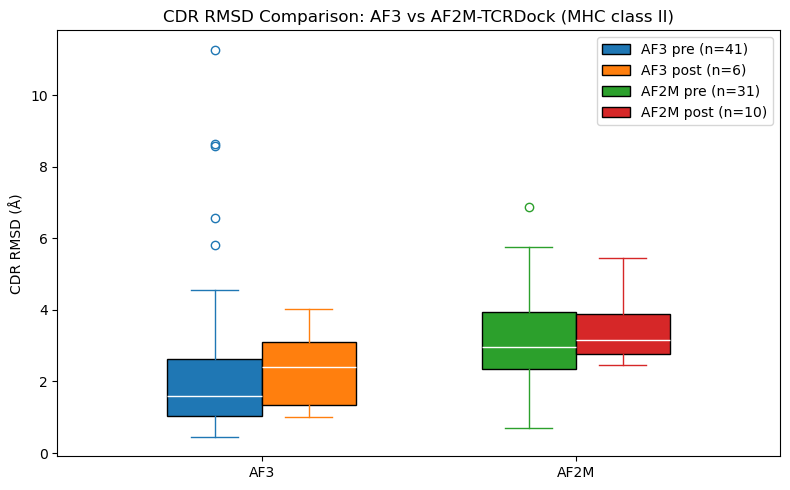

In [5]:
fig = plot_rmsd_compare_af(
    pdb_af3.filter(pl.col("mhc_class") == "II"),
    title="CDR RMSD Comparison: AF3 vs AF2M-TCRDock (MHC class II)",
)